## 0) Setup & Reproducibility

In [1]:

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def set_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seeds(42)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)


## 1) Load & Merge Data (ARFF → DataFrame)

In [2]:

from scipy.io import arff

# --- Update paths if needed ---
ARFF_FILES = ["1year.arff", "2year.arff", "3year.arff", "4year.arff", "5year.arff"]

dfs = []
for i, fp in enumerate(ARFF_FILES, start=1):
    data, meta = arff.loadarff(fp)
    df_i = pd.DataFrame(data)

    # Decode bytes → str (ARFF often stores as bytes)
    df_i = df_i.applymap(lambda x: x.decode() if isinstance(x, (bytes, bytearray)) else x)

    df_i["Year"] = i
    dfs.append(df_i)

df = pd.concat(dfs, ignore_index=True)
df.shape


C:\Users\ozgek\AppData\Local\Temp\ipykernel_14644\2223489990.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_i = df_i.applymap(lambda x: x.decode() if isinstance(x, (bytes, bytearray)) else x)
C:\Users\ozgek\AppData\Local\Temp\ipykernel_14644\2223489990.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_i = df_i.applymap(lambda x: x.decode() if isinstance(x, (bytes, bytearray)) else x)
C:\Users\ozgek\AppData\Local\Temp\ipykernel_14644\2223489990.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_i = df_i.applymap(lambda x: x.decode() if isinstance(x, (bytes, bytearray)) else x)
C:\Users\ozgek\AppData\Local\Temp\ipykernel_14644\2223489990.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_i = df_i.applymap(lambda x: x.decode() if isinstance(x, (bytes, bytearray)) else x)
C:\Users\ozgek\AppData\Local\Temp\ipykernel_

(43405, 66)

## 2) Basic Cleaning & Split

In [3]:

# Convert numeric-like strings to numbers where possible
df = df.apply(pd.to_numeric, errors="ignore")

# Drop known problematic column (as in your original notebook)
if "Attr37" in df.columns:
    df = df.drop(columns=["Attr37"])

# Target
# In this dataset, the target column is usually named "class"
assert "class" in df.columns, "Target column `class` not found. Check dataset columns."

from sklearn.model_selection import train_test_split

X = df.drop(columns=["class"])
y = df["class"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.value_counts(), y_test.value_counts()


C:\Users\ozgek\AppData\Local\Temp\ipykernel_14644\2889434884.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


((34724, 64),
 (8681, 64),
 class
 0    33051
 1     1673
 Name: count, dtype: int64,
 class
 0    8263
 1     418
 Name: count, dtype: int64)

## 3) Year-median Imputation + Scaling + SMOTE

In [4]:

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# -------- Year-median imputation (same logic as your original) --------
cols = [c for c in X_train.columns if c != "Year"]

year_medians = {col: X_train.groupby("Year")[col].median() for col in cols}
global_medians = {col: X_train[col].median() for col in cols}

def fill_year_median(X_):
    X_ = X_.copy()
    for col in cols:
        X_[col] = X_[col].fillna(X_["Year"].map(year_medians[col]))
        X_[col] = X_[col].fillna(global_medians[col])
    return X_

X_train_ym = fill_year_median(X_train)
X_test_ym  = fill_year_median(X_test)

# -------- Scale (keep Year as a feature) --------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ym)
X_test_scaled  = scaler.transform(X_test_ym)

# -------- SMOTE on training only --------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

y_train.value_counts(), y_train_res.value_counts()


(class
 0    33051
 1     1673
 Name: count, dtype: int64,
 class
 0    33051
 1    33051
 Name: count, dtype: int64)

## 4) Model Zoo (define models in one place)

In [5]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

MODELS = {}

# Logistic Regression
MODELS["LogReg"] = LogisticRegression(max_iter=1000, solver="lbfgs")

# Random Forest
MODELS["RandomForest"] = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# SVM (RBF) — use probability=True to enable predict_proba
MODELS["SVM_RBF"] = SVC(
    kernel="rbf",
    C=2.0,
    gamma="scale",
    probability=True,
    random_state=42
)

# Simple Neural Net (sklearn MLP)
MODELS["MLP_sklearn"] = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

# LightGBM (optional)
try:
    from lightgbm import LGBMClassifier
    MODELS["LightGBM"] = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
except Exception as e:
    print("LightGBM not available -> skipping. Reason:", repr(e))

# XGBoost (optional)
try:
    from xgboost import XGBClassifier
    MODELS["XGBoost"] = XGBClassifier(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    )
except Exception as e:
    print("XGBoost not available -> skipping. Reason:", repr(e))

# CatBoost (optional)
try:
    from catboost import CatBoostClassifier
    MODELS["CatBoost"] = CatBoostClassifier(
        iterations=800,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        verbose=False,
        random_seed=42
    )
except Exception as e:
    print("CatBoost not available -> skipping. Reason:", repr(e))

list(MODELS.keys())


['LogReg',
 'RandomForest',
 'SVM_RBF',
 'MLP_sklearn',
 'LightGBM',
 'XGBoost',
 'CatBoost']

## 5) Train/Evaluate All Models (single loop)

In [6]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

def get_proba_or_score(model, X):
    '''
    Returns a 1D array in [0,1] if possible.
    - predict_proba -> positive class probability
    - decision_function -> sigmoid to approximate probability
    - else None
    '''
    if hasattr(model, "predict_proba"):
        try:
            return model.predict_proba(X)[:, 1]
        except Exception:
            return None
    if hasattr(model, "decision_function"):
        try:
            s = model.decision_function(X)
            return 1 / (1 + np.exp(-s))
        except Exception:
            return None
    return None

def evaluate(y_true, y_pred, y_proba=None):
    out = {}
    out["accuracy"]  = accuracy_score(y_true, y_pred)
    out["precision"] = precision_score(y_true, y_pred, zero_division=0)
    out["recall"]    = recall_score(y_true, y_pred, zero_division=0)
    out["f1"]        = f1_score(y_true, y_pred)

    out["roc_auc"] = roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    out["pr_auc"]  = average_precision_score(y_true, y_proba) if y_proba is not None else np.nan
    out["cm"]      = confusion_matrix(y_true, y_pred)
    return out

def find_best_threshold(y_true, y_proba, metric="f1", n=501):
    from sklearn.metrics import f1_score, precision_score, recall_score
    ths = np.linspace(0, 1, n)

    best_t, best_val = 0.5, -1.0
    for t in ths:
        yp = (y_proba >= t).astype(int)
        if metric == "f1":
            val = f1_score(y_true, yp)
        elif metric == "precision":
            val = precision_score(y_true, yp, zero_division=0)
        elif metric == "recall":
            val = recall_score(y_true, yp, zero_division=0)
        else:
            raise ValueError("metric must be one of: f1, precision, recall")

        if val > best_val:
            best_val, best_t = float(val), float(t)

    return best_t, best_val

results = []
store = {}  # per-model cache (preds, probas, metrics, etc.)

for name, model in MODELS.items():
    print(f"\n=== Training: {name} ===")
    model.fit(X_train_res, y_train_res)

    y_pred = model.predict(X_test_scaled)
    y_proba = get_proba_or_score(model, X_test_scaled)

    m = evaluate(y_test, y_pred, y_proba)

    # Optional threshold tuning (only if proba exists)
    best_thr = np.nan
    m_thr = None
    if y_proba is not None:
        best_thr, best_f1 = find_best_threshold(y_test, y_proba, metric="f1")
        y_pred_thr = (y_proba >= best_thr).astype(int)
        m_thr = evaluate(y_test, y_pred_thr, y_proba)

    results.append({
        "model": name,
        "accuracy": m["accuracy"],
        "precision": m["precision"],
        "recall": m["recall"],
        "f1": m["f1"],
        "roc_auc": m["roc_auc"],
        "pr_auc": m["pr_auc"],
        "best_thr_f1": best_thr,
        "f1_at_best_thr": (m_thr["f1"] if m_thr is not None else np.nan)
    })

    store[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "metrics_0_5": m,
        "metrics_best_thr": m_thr,
        "best_thr": best_thr
    }

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
results_df



=== Training: LogReg ===

=== Training: RandomForest ===

=== Training: SVM_RBF ===

=== Training: MLP_sklearn ===

=== Training: LightGBM ===
[LightGBM] [Info] Number of positive: 33051, number of negative: 33051
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013399 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16320
[LightGBM] [Info] Number of data points in the train set: 66102, number of used features: 64
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\ozgek\.conda\envs\tf310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\ozgek\.conda\envs\tf310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Training: XGBoost ===

=== Training: CatBoost ===


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,best_thr_f1,f1_at_best_thr
0,LightGBM,0.978574,0.847305,0.677033,0.752660,0.975731,0.825864,0.476,0.755906
1,XGBoost,0.977768,0.829912,0.677033,0.745718,0.972103,0.817046,0.554,0.750678
2,CatBoost,0.972929,0.729323,0.696172,0.712362,0.969243,0.791167,0.600,0.718367
3,RandomForest,0.956111,0.544578,0.540670,0.542617,0.927221,0.557207,0.528,0.550063
4,MLP_sklearn,0.903122,0.252052,0.514354,0.338316,0.825103,0.276194,0.756,0.371134
5,SVM_RBF,0.688976,0.099649,0.679426,0.173807,0.732658,0.125507,0.662,0.214548
6,LogReg,0.721000,0.100797,0.605263,0.172814,0.727964,0.130449,0.570,0.219065


## 6) Pick Best Model + Threshold Tuning + Plots

Best model by F1 @0.5: LightGBM

Classification Report (thr=0.5):
              precision    recall  f1-score   support

           0      0.984     0.994     0.989      8263
           1      0.847     0.677     0.753       418

    accuracy                          0.979      8681
   macro avg      0.916     0.835     0.871      8681
weighted avg      0.977     0.979     0.977      8681

Confusion Matrix:
 [[8212   51]
 [ 135  283]]

Best threshold (max F1): 0.476

Classification Report (best thr):
              precision    recall  f1-score   support

           0      0.984     0.993     0.989      8263
           1      0.837     0.689     0.756       418

    accuracy                          0.979      8681
   macro avg      0.911     0.841     0.872      8681
weighted avg      0.977     0.979     0.978      8681

Confusion Matrix (best thr):
 [[8207   56]
 [ 130  288]]


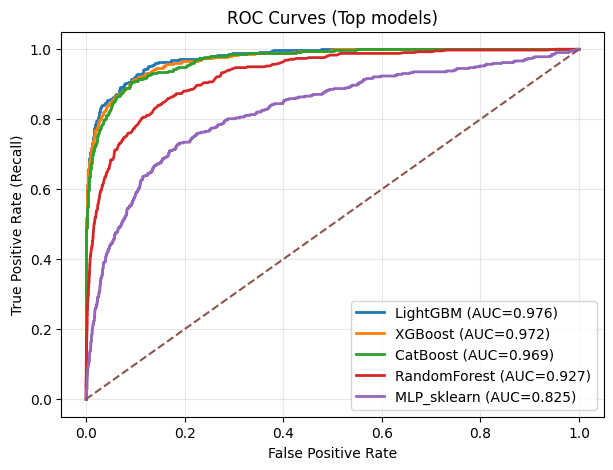

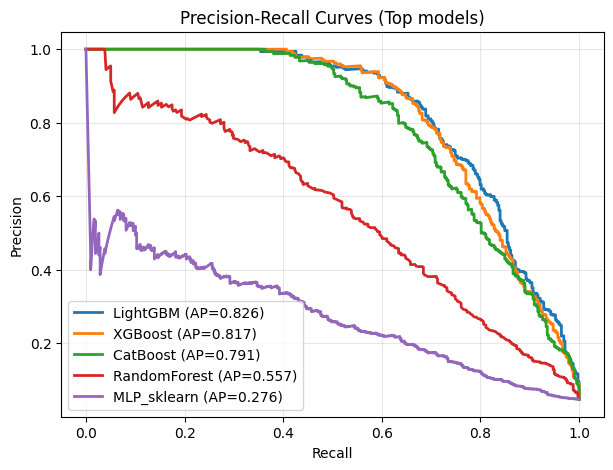

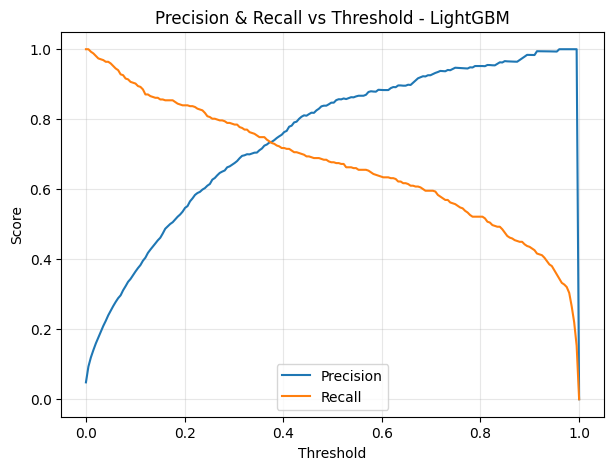

In [7]:

best_model_name = results_df.loc[0, "model"]
best = store[best_model_name]

print("Best model by F1 @0.5:", best_model_name)
print("\nClassification Report (thr=0.5):")
print(classification_report(y_test, best["y_pred"], digits=3))
print("Confusion Matrix:\n", best["metrics_0_5"]["cm"])

if best["y_proba"] is not None and not np.isnan(best["best_thr"]):
    y_pred_opt = (best["y_proba"] >= best["best_thr"]).astype(int)
    print(f"\nBest threshold (max F1): {best['best_thr']:.3f}")
    print("\nClassification Report (best thr):")
    print(classification_report(y_test, y_pred_opt, digits=3))
    print("Confusion Matrix (best thr):\n", confusion_matrix(y_test, y_pred_opt))

# ---- ROC & PR curves for top K models (with proba) ----
top_k = min(5, len(results_df))

plt.figure(figsize=(7,5))
for name in results_df["model"].head(top_k):
    proba = store[name]["y_proba"]
    if proba is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, proba)
    aucv = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={aucv:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves (Top models)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7,5))
for name in results_df["model"].head(top_k):
    proba = store[name]["y_proba"]
    if proba is None:
        continue
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(rec, prec, lw=2, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Top models)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---- Precision & Recall vs Threshold for best model ----
if best["y_proba"] is not None:
    ths = np.linspace(0.0, 1.0, 200)
    precisions = []
    recalls = []
    for t in ths:
        yp = (best["y_proba"] >= t).astype(int)
        precisions.append(precision_score(y_test, yp, zero_division=0))
        recalls.append(recall_score(y_test, yp, zero_division=0))

    plt.figure(figsize=(7,5))
    plt.plot(ths, precisions, label="Precision")
    plt.plot(ths, recalls, label="Recall")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(f"Precision & Recall vs Threshold - {best_model_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


## 7) Optional: Feature Importance (if supported)

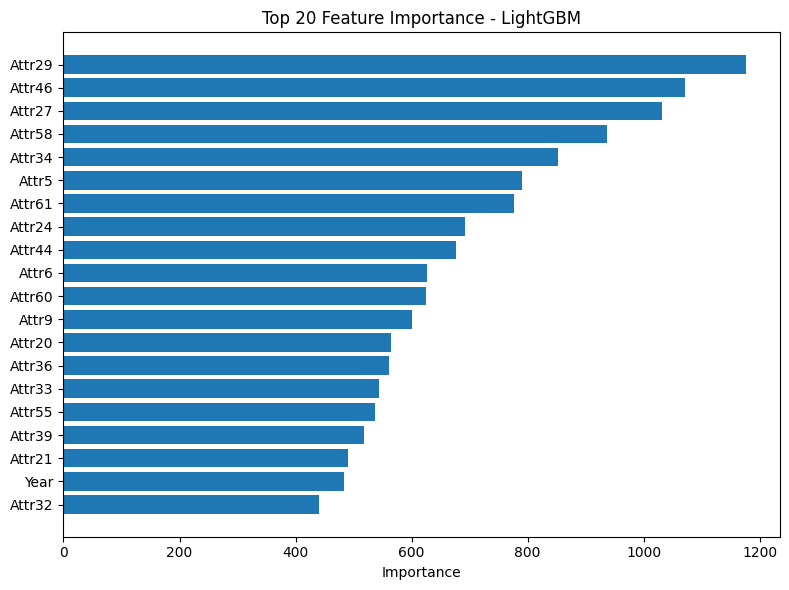

In [8]:

def plot_feature_importance(model, feature_names, top_n=20):
    importances = None
    if hasattr(model, "feature_importances_"):
        importances = getattr(model, "feature_importances_")
    elif hasattr(model, "coef_"):
        coef = getattr(model, "coef_")
        importances = np.abs(coef[0]) if len(coef.shape) > 1 else np.abs(coef)
    else:
        print("❌ This model does not support feature importance via feature_importances_ or coef_.")
        return

    fi = pd.DataFrame({"feature": feature_names, "importance": importances})
    fi = fi.sort_values("importance", ascending=False).head(top_n)

    plt.figure(figsize=(8,6))
    plt.barh(fi["feature"][::-1], fi["importance"][::-1])
    plt.title(f"Top {top_n} Feature Importance - {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

feature_names = list(X_train_ym.columns)
plot_feature_importance(best["model"], feature_names, top_n=20)


## Appendix: Complex Neural Network (TensorFlow/Keras) (Optional)

Kept separate from the main loop because it has a different training API.


In [9]:

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.callbacks import EarlyStopping

    set_seeds(42)
    tf.random.set_seed(42)

    keras_model = Sequential([
        Dense(256, activation="relu", input_shape=(X_train_res.shape[1],)),
        BatchNormalization(),
        Dropout(0.4),

        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.4),

        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        Dense(1, activation="sigmoid")
    ])

    keras_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="roc_auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = keras_model.fit(
        X_train_res, y_train_res,
        validation_split=0.2,
        epochs=50,
        batch_size=512,
        callbacks=[early_stop],
        verbose=1
    )

    y_proba = keras_model.predict(X_test_scaled).ravel()
    y_pred = (y_proba >= 0.5).astype(int)

    print("\nKeras NN Report (thr=0.5):")
    print(classification_report(y_test, y_pred, digits=3))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nROC-AUC :", roc_auc_score(y_test, y_proba))
    print("PR-AUC  :", average_precision_score(y_test, y_proba))

    best_thr, best_f1 = find_best_threshold(y_test, y_proba, metric="f1")
    y_pred_opt = (y_proba >= best_thr).astype(int)
    print(f"\nBest threshold (max F1): {best_thr:.3f}  Best F1: {best_f1:.3f}")
    print("\nKeras NN Report (best thr):")
    print(classification_report(y_test, y_pred_opt, digits=3))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_opt))

except Exception as e:
    print("TensorFlow/Keras not available -> skipping. Reason:", repr(e))


c:\Users\ozgek\.conda\envs\tf310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.7005 - pr_auc: 0.4723 - roc_auc: 0.6079 - val_loss: 1.0546 - val_pr_auc: 1.0000 - val_roc_auc: 0.0000e+00
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6225 - pr_auc: 0.5665 - roc_auc: 0.6918 - val_loss: 1.0472 - val_pr_auc: 1.0000 - val_roc_auc: 0.0000e+00
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5941 - pr_auc: 0.5998 - roc_auc: 0.7283 - val_loss: 1.0049 - val_pr_auc: 1.0000 - val_roc_auc: 0.0000e+00
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5751 - pr_auc: 0.6174 - roc_auc: 0.7479 - val_loss: 0.9690 - val_pr_auc: 1.0000 - val_roc_auc: 0.0000e+00
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5631 - pr_auc: 0.6306 - roc_auc: 0.7591 - val_loss: 0.9619 - val_pr_auc: 1.0000 - val_roc_auc: 0.0000e+00
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5482 - pr_auc: 0.6491 - roc_auc: 0.7731 - val_loss: 0.9834 - val_pr_auc: 1.0000 - val_roc_auc: